# Analyzing the Dataset

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
data_ps4 = pd.read_csv('PS4_GamesSales.csv', encoding='latin1')
data_ps4.head()

,Game,Year,Genre,Publisher,North America,Europe,Japan,Rest of World,Global
0,Grand Theft Auto V,2014.0,Action,Rockstar Games,6.06,9.71,0.60,3.02,19.39
1,Call of Duty: Black Ops 3,2015.0,Shooter,Activision,6.18,6.05,0.41,2.44,15.09
2,Red Dead Redemption 2,2018.0,Action-Adventure,Rockstar Games,5.26,6.21,0.21,2.26,13.94
3,Call of Duty: WWII,2017.0,Shooter,Activision,4.67,6.21,0.40,2.12,13.40
4,FIFA 18,2017.0,Sports,EA Sports,1.27,8.64,0.15,1.73,11.80


In [4]:
data_xbox = pd.read_csv('XboxOne_GameSales.csv', encoding = 'latin1')
data_xbox.head()

,Pos,Game,Year,Genre,Publisher,North America,Europe,Japan,Rest of World,Global
0,1,Grand Theft Auto V,2014.0,Action,Rockstar Games,4.70,3.25,0.01,0.76,8.72
1,2,Call of Duty: Black Ops 3,2015.0,Shooter,Activision,4.63,2.04,0.02,0.68,7.37
2,3,Call of Duty: WWII,2017.0,Shooter,Activision,3.75,1.91,0.00,0.57,6.23
3,4,Red Dead Redemption 2,2018.0,Action-Adventure,Rockstar Games,3.76,1.47,0.00,0.54,5.77
4,5,MineCraft,2014.0,Misc,Microsoft Studios,3.23,1.71,0.00,0.49,5.43


In [5]:
sns.set_style('darkgrid')

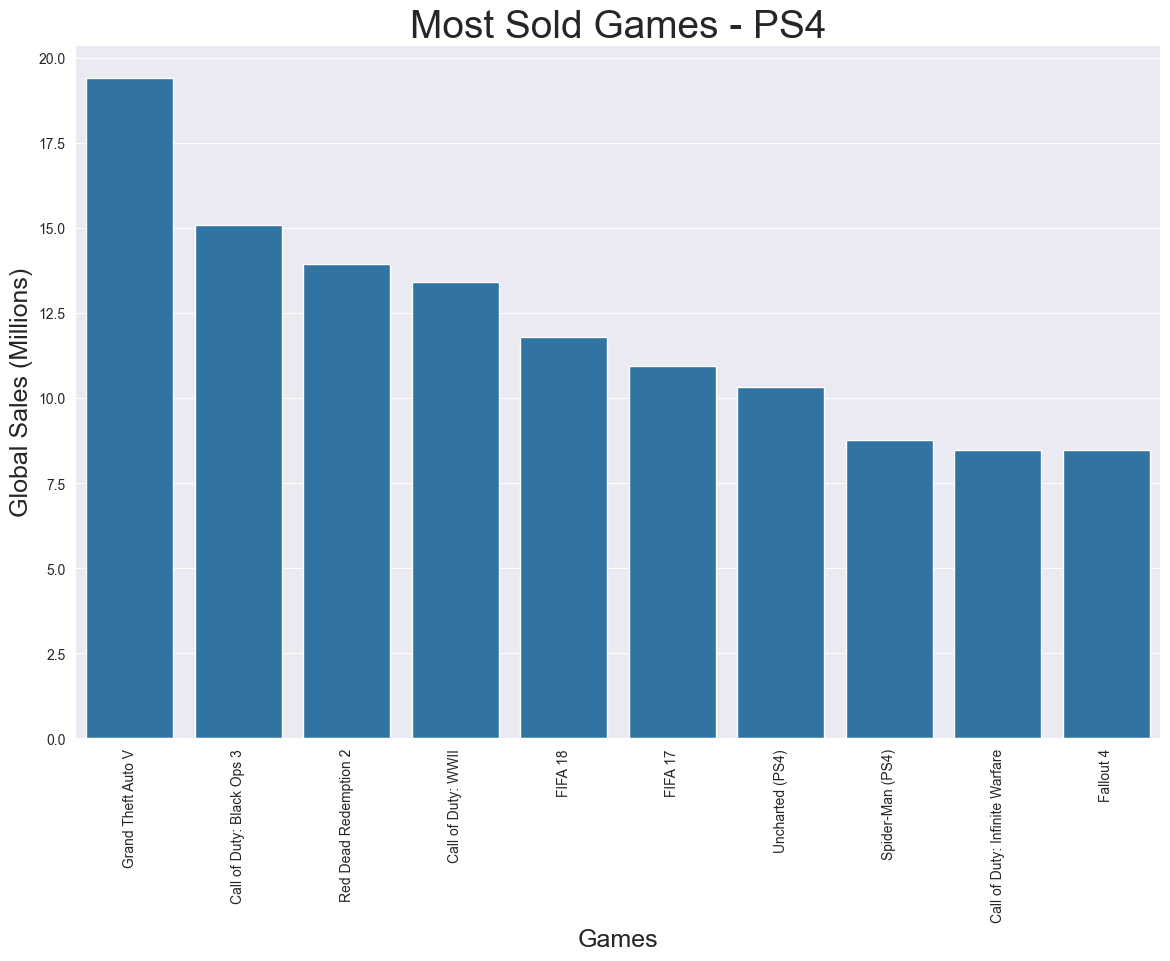

In [6]:
ax = sns.barplot(x = 'Game', y = "Global", data = data_ps4[:10])
ax.figure.set_size_inches(14, 9)
ax.set_title("Most Sold Games - PS4", fontsize = 28)
ax.set_ylabel('Global Sales (Millions)', fontsize = 18)
ax.set_xlabel('Games', fontsize = 18)
plt.xticks(rotation = 90)
plt.show()

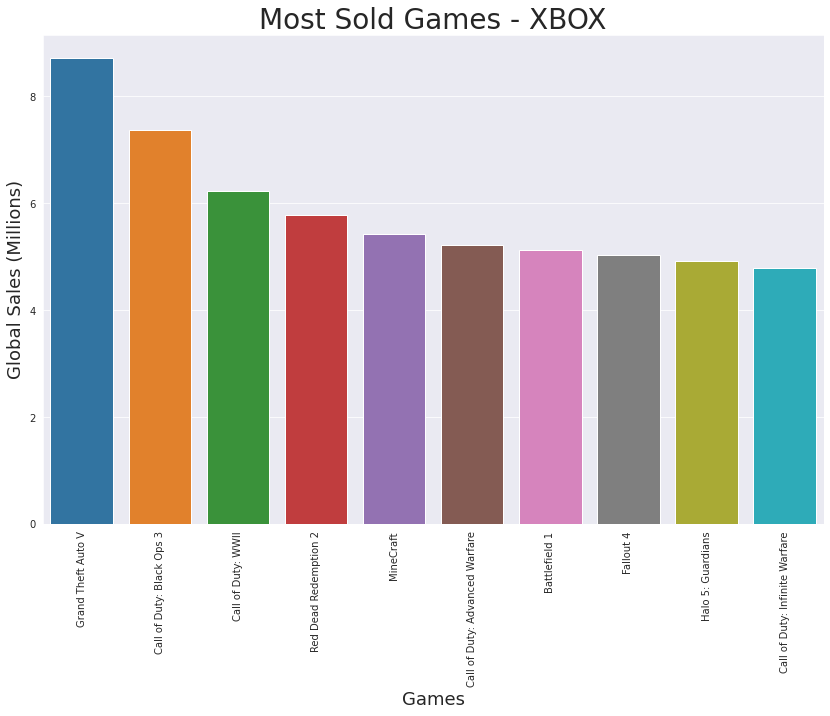

In [6]:
ax = sns.barplot(x = 'Game', y = "Global", data = data_xbox[:10])
ax.figure.set_size_inches(14, 9)
ax.set_title("Most Sold Games - XBOX", fontsize = 28)
ax.set_ylabel('Global Sales (Millions)', fontsize = 18)
ax.set_xlabel('Games', fontsize = 18)
plt.xticks(rotation = 90)
plt.show()

In [7]:
data_ps4.insert(0, 'Game_ID', range(len(data_ps4)))

In [8]:
data_ps4 = data_ps4.set_index('Game_ID')

In [9]:
data_ps4.head()

,Game,Year,Genre,Publisher,North America,Europe,Japan,Rest of World,Global
Game_ID,,,,,,,,,
0,Grand Theft Auto V,2014.0,Action,Rockstar Games,6.06,9.71,0.60,3.02,19.39
1,Call of Duty: Black Ops 3,2015.0,Shooter,Activision,6.18,6.05,0.41,2.44,15.09
2,Red Dead Redemption 2,2018.0,Action-Adventure,Rockstar Games,5.26,6.21,0.21,2.26,13.94
3,Call of Duty: WWII,2017.0,Shooter,Activision,4.67,6.21,0.40,2.12,13.40
4,FIFA 18,2017.0,Sports,EA Sports,1.27,8.64,0.15,1.73,11.80


The game ID was added for each game in Playstation 4 and the code below adds the same Game ID for games that already has been showed up, otherwise it creates  a new game id.

In [10]:
game_ids = list()

for i, game_name in enumerate(data_xbox['Game']):  
  if data_ps4['Game'].str.contains(game_name).any():
    game_id = data_ps4.query('Game == "%s"' % game_name).index
    
    if len(game_id) == 0:
      game_id = len(data_ps4) + i + 1
    else:
      game_id = game_id[0]

  else:
    game_id = len(data_ps4) + i + 1

  game_ids.append(game_id)

C:\Users\91908\AppData\Local\Temp\ipykernel_13872\242856474.py:4: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  if data_ps4['Game'].str.contains(game_name).any():
C:\Users\91908\AppData\Local\Temp\ipykernel_13872\242856474.py:4: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  if data_ps4['Game'].str.contains(game_name).any():
C:\Users\91908\AppData\Local\Temp\ipykernel_13872\242856474.py:4: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  if data_ps4['Game'].str.contains(game_name).any():
C:\Users\91908\AppData\Local\Temp\ipykernel_13872\242856474.py:4: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  if data_ps4['Game'].str.contains(game_name)

In [11]:
data_xbox.insert(0, 'Game_ID', game_ids)

In [12]:
data_xbox = data_xbox.set_index('Game_ID')
data_xbox = data_xbox.drop('Pos', axis=1)
data_xbox.head()

,Game,Year,Genre,Publisher,North America,Europe,Japan,Rest of World,Global
Game_ID,,,,,,,,,
0,Grand Theft Auto V,2014.0,Action,Rockstar Games,4.70,3.25,0.01,0.76,8.72
1,Call of Duty: Black Ops 3,2015.0,Shooter,Activision,4.63,2.04,0.02,0.68,7.37
3,Call of Duty: WWII,2017.0,Shooter,Activision,3.75,1.91,0.00,0.57,6.23
2,Red Dead Redemption 2,2018.0,Action-Adventure,Rockstar Games,3.76,1.47,0.00,0.54,5.77
15,MineCraft,2014.0,Misc,Microsoft Studios,3.23,1.71,0.00,0.49,5.43


In [13]:
inner_join_games = data_ps4.join(data_xbox[['North America', 'Europe', 'Japan', 'Rest of World', 'Global']], how = 'inner', rsuffix='_xbox', lsuffix = '_ps4')

In [14]:
inner_join_games

,Game,Year,Genre,Publisher,North America_ps4,Europe_ps4,Japan_ps4,Rest of World_ps4,Global_ps4,North America_xbox,Europe_xbox,Japan_xbox,Rest of World_xbox,Global_xbox
Game_ID,,,,,,,,,,,,,,
0,Grand Theft Auto V,2014.0,Action,Rockstar Games,6.06,9.71,0.60,3.02,19.39,4.70,3.25,0.01,0.76,8.72
1,Call of Duty: Black Ops 3,2015.0,Shooter,Activision,6.18,6.05,0.41,2.44,15.09,4.63,2.04,0.02,0.68,7.37
2,Red Dead Redemption 2,2018.0,Action-Adventure,Rockstar Games,5.26,6.21,0.21,2.26,13.94,3.76,1.47,0.00,0.54,5.77
3,Call of Duty: WWII,2017.0,Shooter,Activision,4.67,6.21,0.40,2.12,13.40,3.75,1.91,0.00,0.57,6.23
4,FIFA 18,2017.0,Sports,EA Sports,1.27,8.64,0.15,1.73,11.80,0.98,1.92,0.00,0.23,3.14
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1023,Iron Harvest,2018.0,Strategy,Unknown,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
1024,Biomutant,2018.0,Action,THQ Nordic,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
1024,Biomutant,2018.0,Action,THQ Nordic,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00


# Processing the data for Analysis

In [15]:
inner_join_games['Global'] = inner_join_games['Global_ps4'] + inner_join_games['Global_xbox']

In [16]:
inner_join_games.isnull().sum()

Game                   0
Year                  58
Genre                  0
Publisher             58
North America_ps4      0
Europe_ps4             0
Japan_ps4              0
Rest of World_ps4      0
Global_ps4             0
North America_xbox     0
Europe_xbox            0
Japan_xbox             0
Rest of World_xbox     0
Global_xbox            0
Global                 0
dtype: int64

In [17]:
inner_join_games = inner_join_games.drop(['Publisher'], axis = 1)
inner_join_games = inner_join_games.fillna(method='ffill')

C:\Users\91908\AppData\Local\Temp\ipykernel_13872\2664964083.py:2: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  inner_join_games = inner_join_games.fillna(method='ffill')


In [18]:
print(inner_join_games.isnull().sum())
inner_join_games.head()

Game                  0
Year                  0
Genre                 0
North America_ps4     0
Europe_ps4            0
Japan_ps4             0
Rest of World_ps4     0
Global_ps4            0
North America_xbox    0
Europe_xbox           0
Japan_xbox            0
Rest of World_xbox    0
Global_xbox           0
Global                0
dtype: int64


,Game,Year,Genre,North America_ps4,Europe_ps4,Japan_ps4,Rest of World_ps4,Global_ps4,North America_xbox,Europe_xbox,Japan_xbox,Rest of World_xbox,Global_xbox,Global
Game_ID,,,,,,,,,,,,,,
0,Grand Theft Auto V,2014.0,Action,6.06,9.71,0.60,3.02,19.39,4.70,3.25,0.01,0.76,8.72,28.11
1,Call of Duty: Black Ops 3,2015.0,Shooter,6.18,6.05,0.41,2.44,15.09,4.63,2.04,0.02,0.68,7.37,22.46
2,Red Dead Redemption 2,2018.0,Action-Adventure,5.26,6.21,0.21,2.26,13.94,3.76,1.47,0.00,0.54,5.77,19.71
3,Call of Duty: WWII,2017.0,Shooter,4.67,6.21,0.40,2.12,13.40,3.75,1.91,0.00,0.57,6.23,19.63
4,FIFA 18,2017.0,Sports,1.27,8.64,0.15,1.73,11.80,0.98,1.92,0.00,0.23,3.14,14.94


# Comparing Consoles

From the previous inner join, let's compare games that are both in PS4 and Xbox.

In [19]:
most_sold = inner_join_games.sort_values('Global', ascending = False)

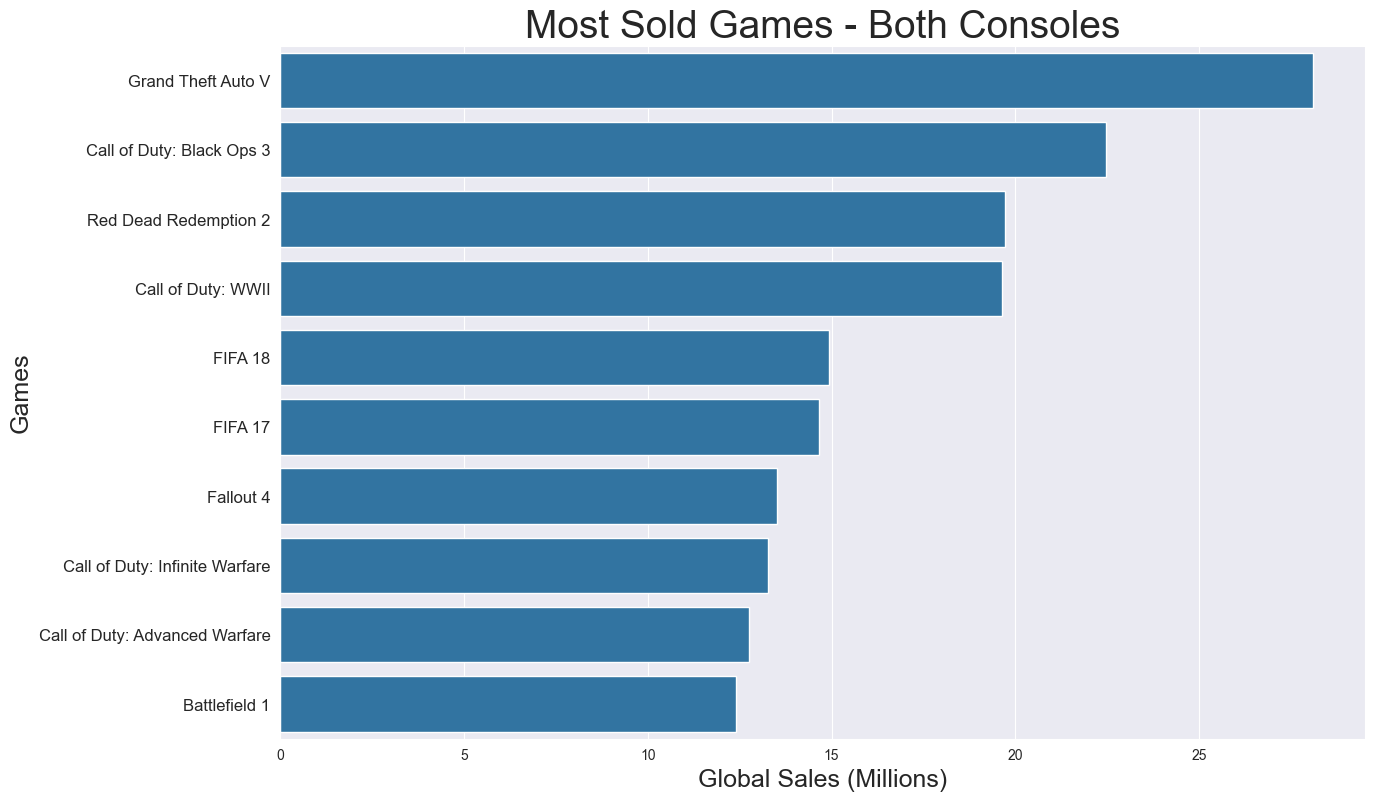

In [20]:
ax = sns.barplot(y = 'Game', x = "Global", data = most_sold[:10])
ax.figure.set_size_inches(14, 9)
ax.set_title("Most Sold Games - Both Consoles", fontsize = 28)
ax.set_xlabel('Global Sales (Millions)', fontsize = 18)
ax.set_ylabel('Games', fontsize = 18)
plt.yticks(fontsize = 12)
plt.show()

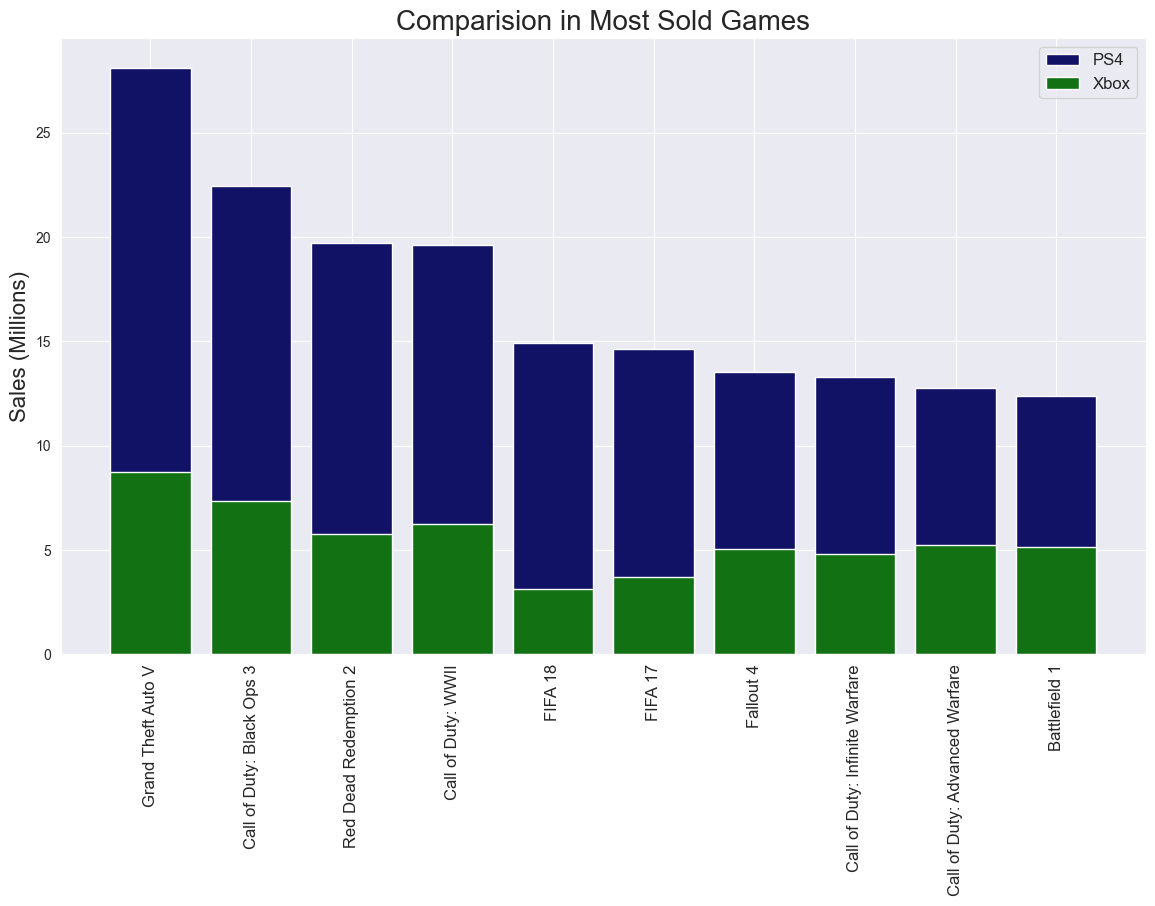

In [21]:
plt.rc('figure', figsize = (14, 8))
plt.bar(most_sold['Game'][:10], most_sold['Global'][:10], color = '#111166')
plt.bar(most_sold['Game'][:10], most_sold['Global_xbox'][:10], color = '#127112')
plt.xticks(rotation = 90, fontsize = 12)
plt.title('Comparision in Most Sold Games', fontsize=20)
plt.ylabel('Sales (Millions)', fontsize = 16)
plt.legend(['PS4', 'Xbox'], fontsize = 12)
plt.show()

PS4 has more users, so it reflects on sales data, where almost every game PS4 has more than 60% of the users. 

Now, let's consider exclusive games.

In [22]:
all_games = pd.concat([data_ps4.reset_index(), data_xbox.reset_index()], ignore_index=True)

In [23]:
all_games = all_games.set_index('Game_ID')

In [24]:
games_only_xbox = all_games.drop(data_ps4.index, errors = 'ignore').sort_values('Global', ascending = False)
games_only_ps4 = all_games.drop(data_xbox.index, errors = 'ignore').sort_values('Global', ascending = False)
games_only_ps4 = games_only_ps4.drop(11)
games_only_xbox = games_only_xbox.drop(1045)
games_only_ps4['Console'] = ['PS4'] * len(games_only_ps4)
games_only_xbox['Console'] = ['Xbox'] * len(games_only_xbox)

In order to find the exclusive games, the code took off the ps4 games from the xbox data and vice versa. The index 11 and 1045 are from Star Wars Battlefront, which isn't a exclusive and have different Game IDs because of the name ('Star Wars Battlefront (2015)' X 'Star Wars Battlefront 2015')

In [25]:
most_sold_exclusive = pd.concat([games_only_ps4.head(), games_only_xbox.head()])

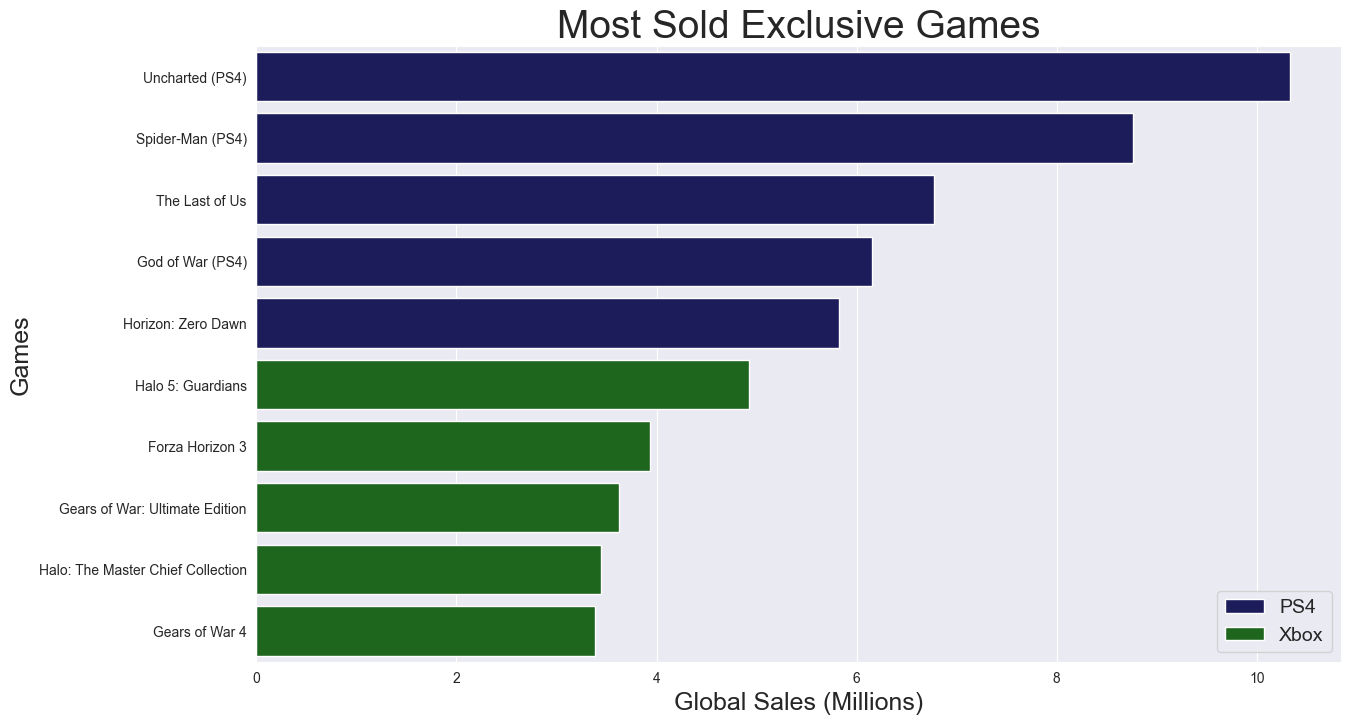

In [26]:
ax = sns.barplot(data = most_sold_exclusive, y = 'Game', x = 'Global', hue = 'Console', palette = ['#111166','#127112'], dodge=False)
ax.figure.set_size_inches(14, 8)
ax.set_title("Most Sold Exclusive Games", fontsize = 28)
ax.set_xlabel('Global Sales (Millions)', fontsize = 18)
ax.set_ylabel('Games', fontsize = 18)
plt.legend(fontsize = 14)
plt.show()

In [27]:
categories_exclusive_ps4 = games_only_ps4.groupby('Genre').sum().sort_values('Global', ascending=False)
categories_exclusive_xbox = games_only_xbox.groupby('Genre').sum().sort_values('Global', ascending=False)
categories_exclusive_ps4['Console'] = ['PS4'] * len(categories_exclusive_ps4)
categories_exclusive_xbox['Console'] = ['Xbox'] * len(categories_exclusive_xbox)
categories_exclusive = pd.concat([categories_exclusive_ps4.reset_index(), categories_exclusive_xbox.reset_index()]).sort_values('Global', ascending=False)

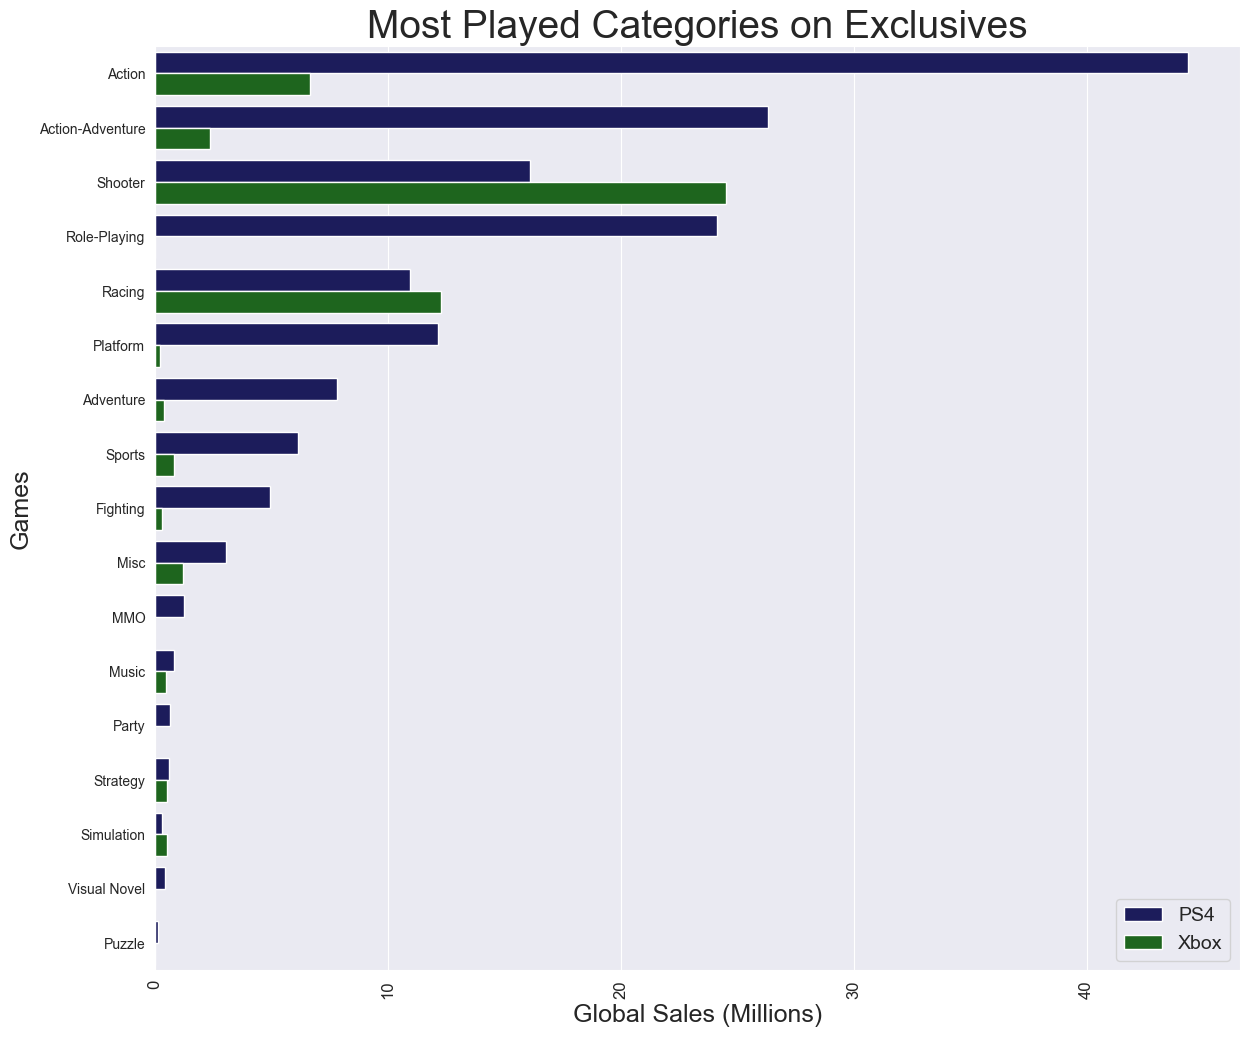

In [28]:
ax = sns.barplot(data = categories_exclusive, y = 'Genre', x = 'Global', hue = 'Console', palette = ['#111166','#127112'])
ax.figure.set_size_inches(14, 12)
ax.set_title("Most Played Categories on Exclusives", fontsize = 28)
ax.set_xlabel('Global Sales (Millions)', fontsize = 18)
ax.set_ylabel('Games', fontsize = 18)
plt.xticks(rotation = 90, fontsize = 12)
plt.legend(fontsize = 14, loc='lower right')
plt.show()

Playstation 4 has sold more games in Action and Role-Playing, increased by Uncharted and Spider-Man. In the other hand, Xbox has more games in genres Racing and Shooter, increased by games like Forza Horizon and Halo.

# Analyzing All Games Through Time

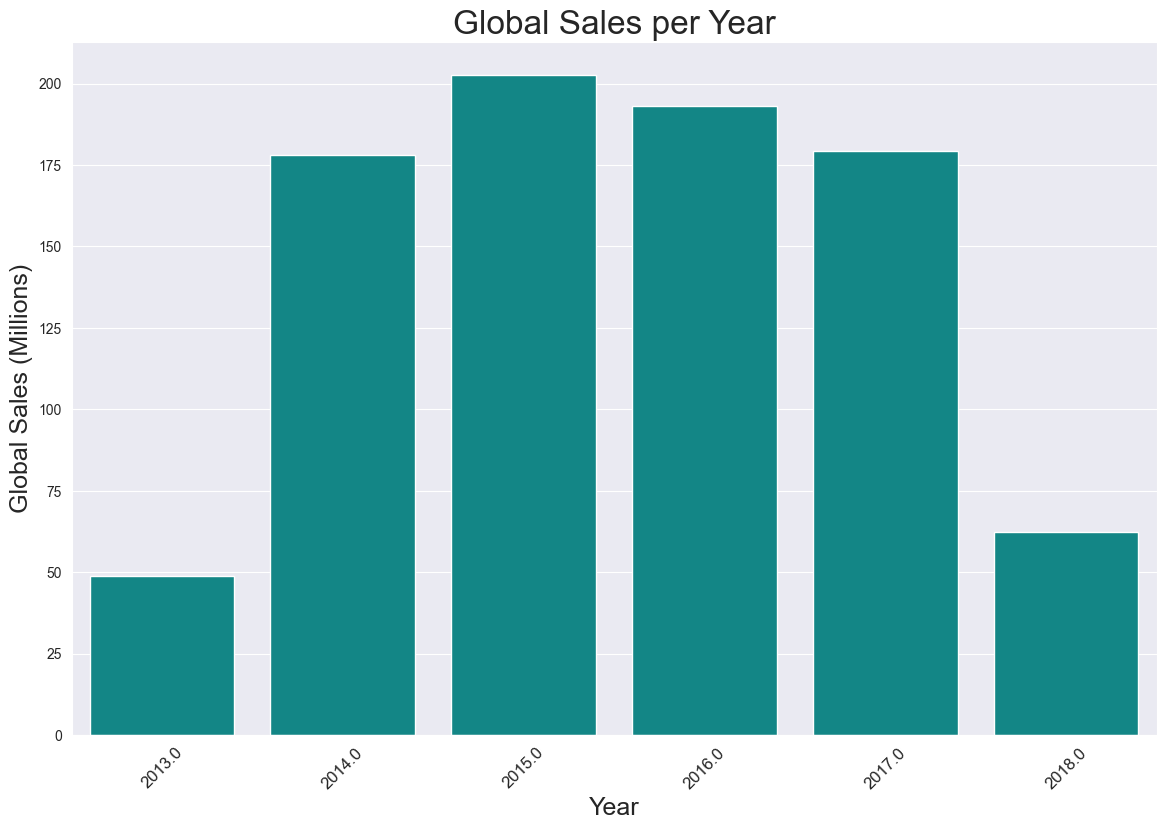

In [29]:
ax = sns.barplot(data = all_games.groupby("Year").sum().head(6).reset_index(), x = 'Year', y = 'Global', color='#009999')
ax.figure.set_size_inches(14, 9)
ax.set_title('Global Sales per Year', fontsize=24)
ax.set_xlabel('Year', fontsize=18)
ax.set_ylabel('Global Sales (Millions)', fontsize=18)
plt.xticks(rotation=45, fontsize=12)
plt.show()

2019 and 2020 don't have any data on sales yet. 

In [30]:
categories_through_years = all_games.groupby(['Genre']).sum().sort_values('Global', ascending=False)
categories_greater_than_20_global = categories_through_years.query('Global > 20')
categories_greater_than_20_global = categories_greater_than_20_global.index.tolist()

In [31]:
most_played_categories = pd.DataFrame()

for genre in categories_greater_than_20_global:
  temp = all_games.query('Genre in "%s"' % genre)
  most_played_categories = pd.concat([most_played_categories, temp])

most_played_categories['Genre'].unique()

array(['Shooter', 'Action', 'Sports', 'Action-Adventure', 'Role-Playing',
       'Racing', 'Fighting', 'Misc', 'Platform', 'Adventure'],
      dtype=object)

C:\Users\91908\AppData\Local\Temp\ipykernel_13872\601737619.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x = categories_through_years.index, y = categories_through_years['Global'], palette = 'bright')


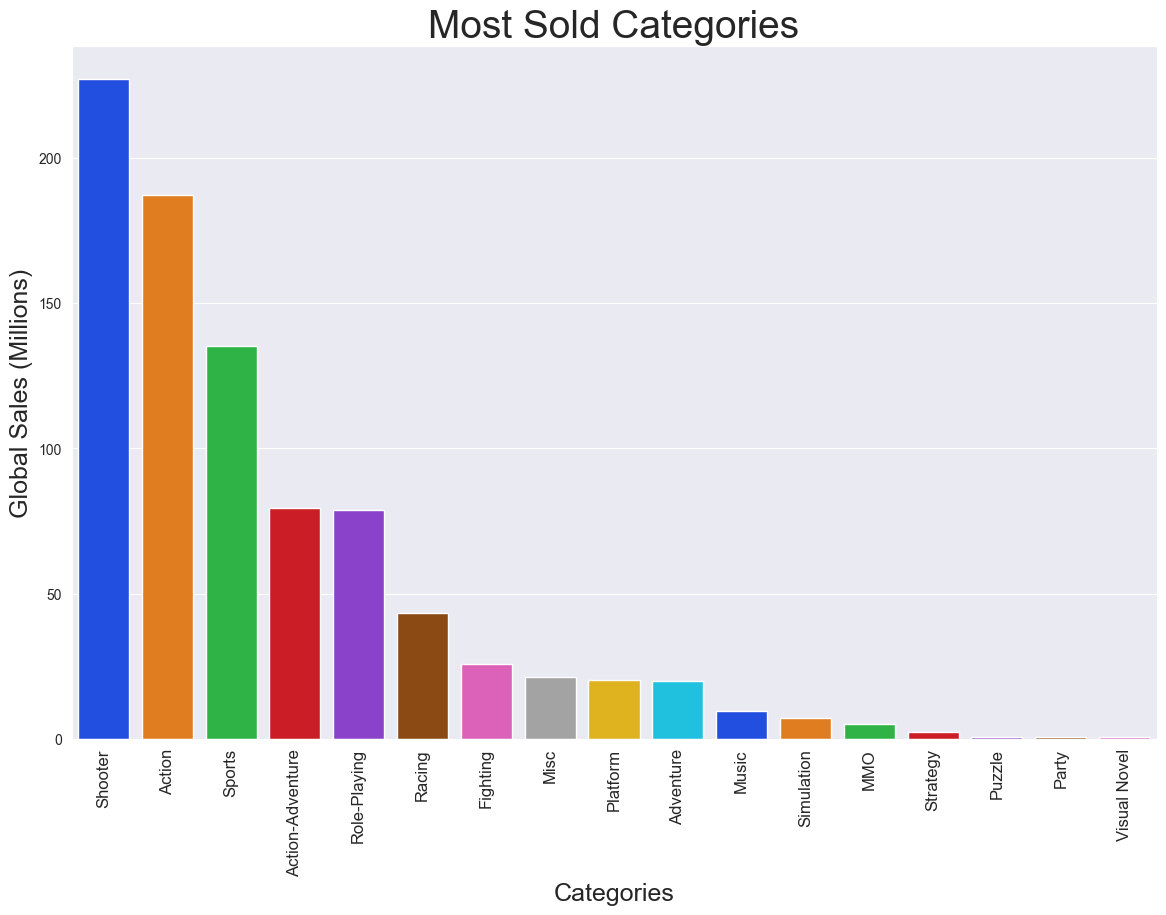

In [32]:
ax = sns.barplot(x = categories_through_years.index, y = categories_through_years['Global'], palette = 'bright')
ax.figure.set_size_inches(14, 9)
ax.set_title("Most Sold Categories", fontsize = 28)
ax.set_ylabel('Global Sales (Millions)', fontsize = 18)
ax.set_xlabel('Categories', fontsize = 18)
plt.xticks(rotation = 90, fontsize = 12)
plt.show()

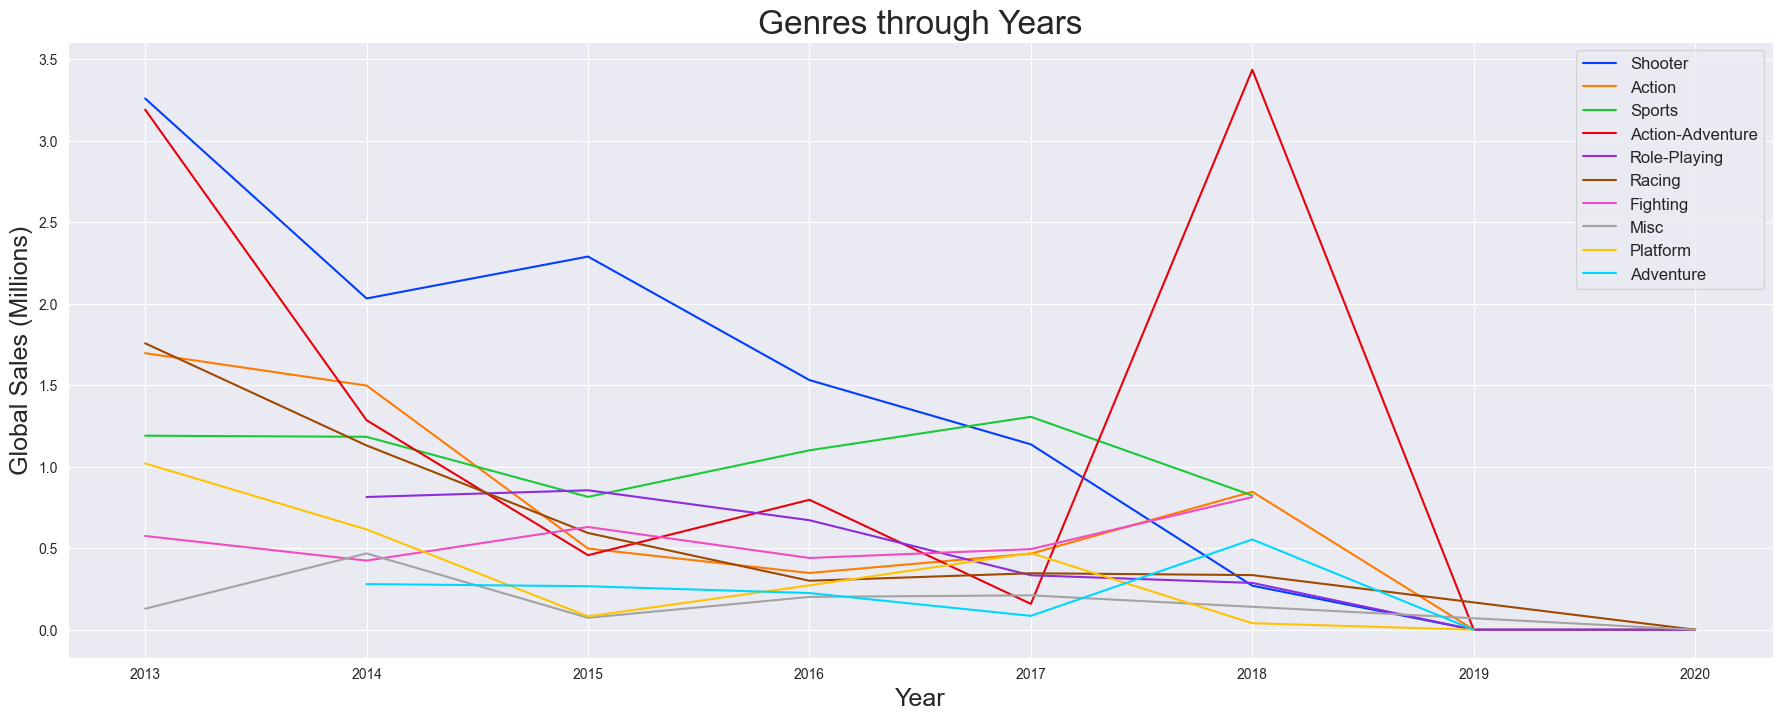

In [33]:
ax = sns.lineplot(x = 'Year', y = 'Global', hue = 'Genre', data = most_played_categories.reset_index(),
                  err_style=None, palette='bright')
ax.figure.set_size_inches(22, 8)
ax.set_title('Genres through Years', fontsize=24)
ax.set_xlabel('Year', fontsize=18)
ax.set_ylabel('Global Sales (Millions)', fontsize=18)
plt.legend(loc = 'upper right', fontsize = 12)
plt.show()

In [34]:
years = all_games.Year.dropna().unique()[:-2]
# Take off 2019 and 2020

As showed in the graph above, 2018 was a great year for Action-Adventure genre games, increased by the sales from Red Dead Redemption 2 and Spider-Man, as it shows in the dataframe below, while Sports Games kept constant great sales. Moreover, the graph below also shows the three most sold games in each year.

In [35]:
games_per_year = pd.DataFrame()

for year in years:
  game_year = pd.DataFrame(all_games.drop_duplicates('Game').reset_index().sort_values('Global', ascending = False) \
                          .query('Year == %d' % int(year)).iloc[:3][['Game', 'Year', 'Global', 'Genre']])
  games_per_year = pd.concat([games_per_year, game_year])

games_per_year = games_per_year.sort_values('Year')

In [36]:
games_per_year.query('Year == 2018')

,Game,Year,Global,Genre
2,Red Dead Redemption 2,2018.0,13.94,Action-Adventure
17,God of War (PS4),2018.0,6.15,Action
7,Spider-Man (PS4),2018.0,8.76,Action-Adventure


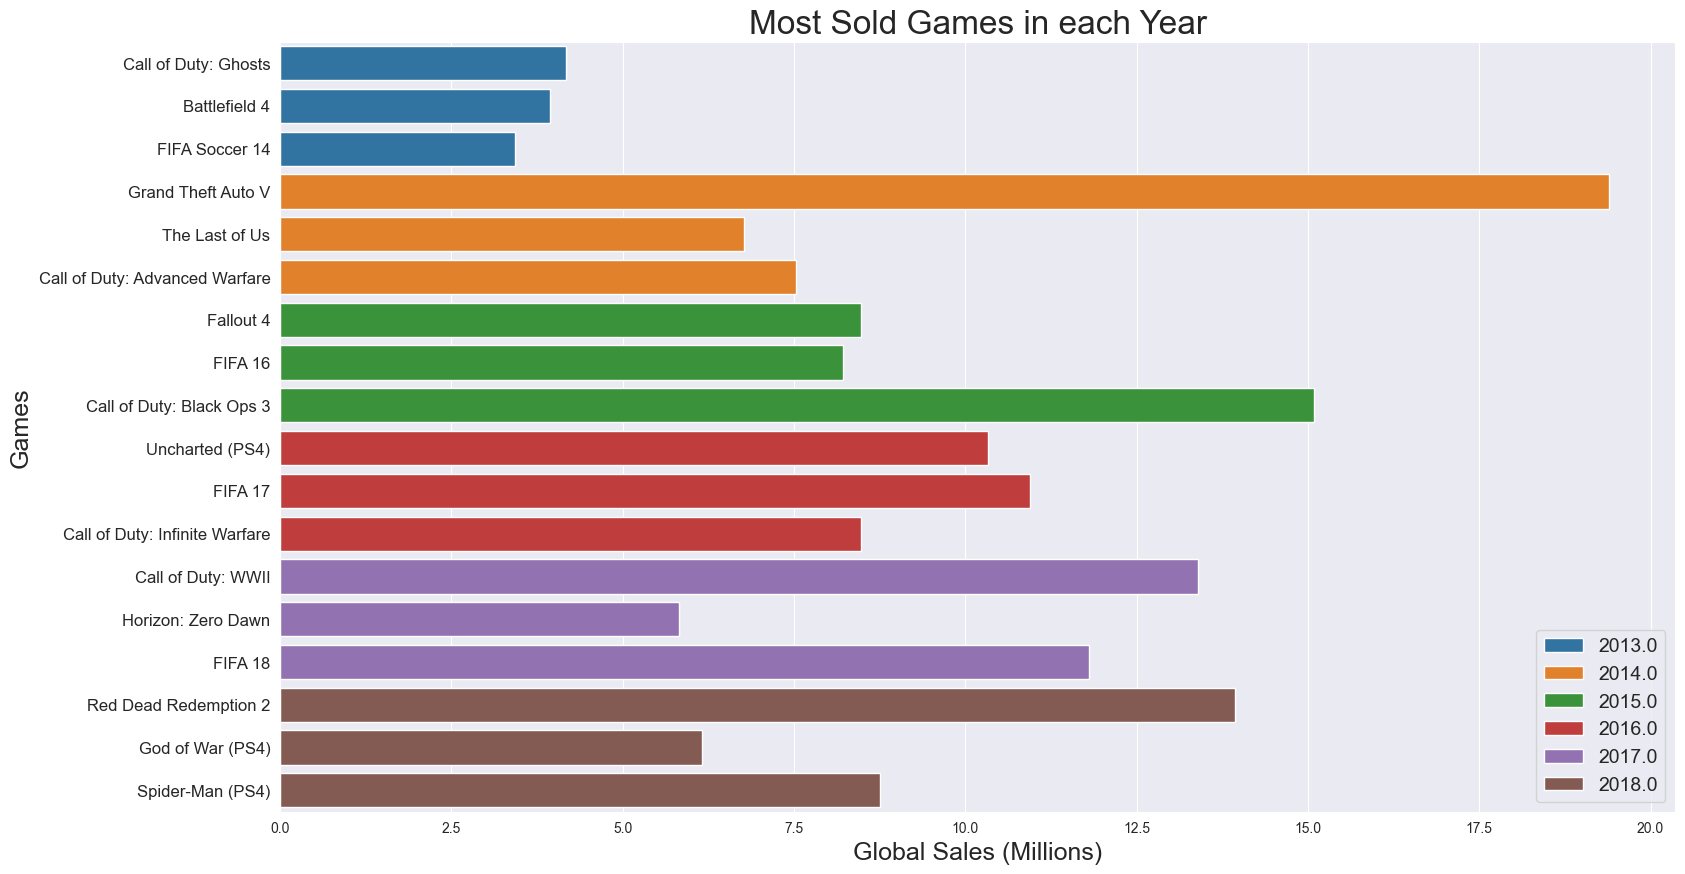

In [37]:
ax = sns.barplot(data = games_per_year, y = 'Game', x = 'Global', hue = 'Year', dodge=False, palette = 'tab10')
ax.set_title('Most Sold Games in each Year', fontsize=24)
ax.set_ylabel('Games', fontsize=18)
ax.set_xlabel('Global Sales (Millions)', fontsize=18)
plt.legend(loc = 'lower right', fontsize = 14)
plt.yticks(fontsize = 12)
ax.figure.set_size_inches(18, 10)
plt.show()

# Analyzing Zones

Firstly, it considers where the revenue from the entire Dataset Game Market come from.

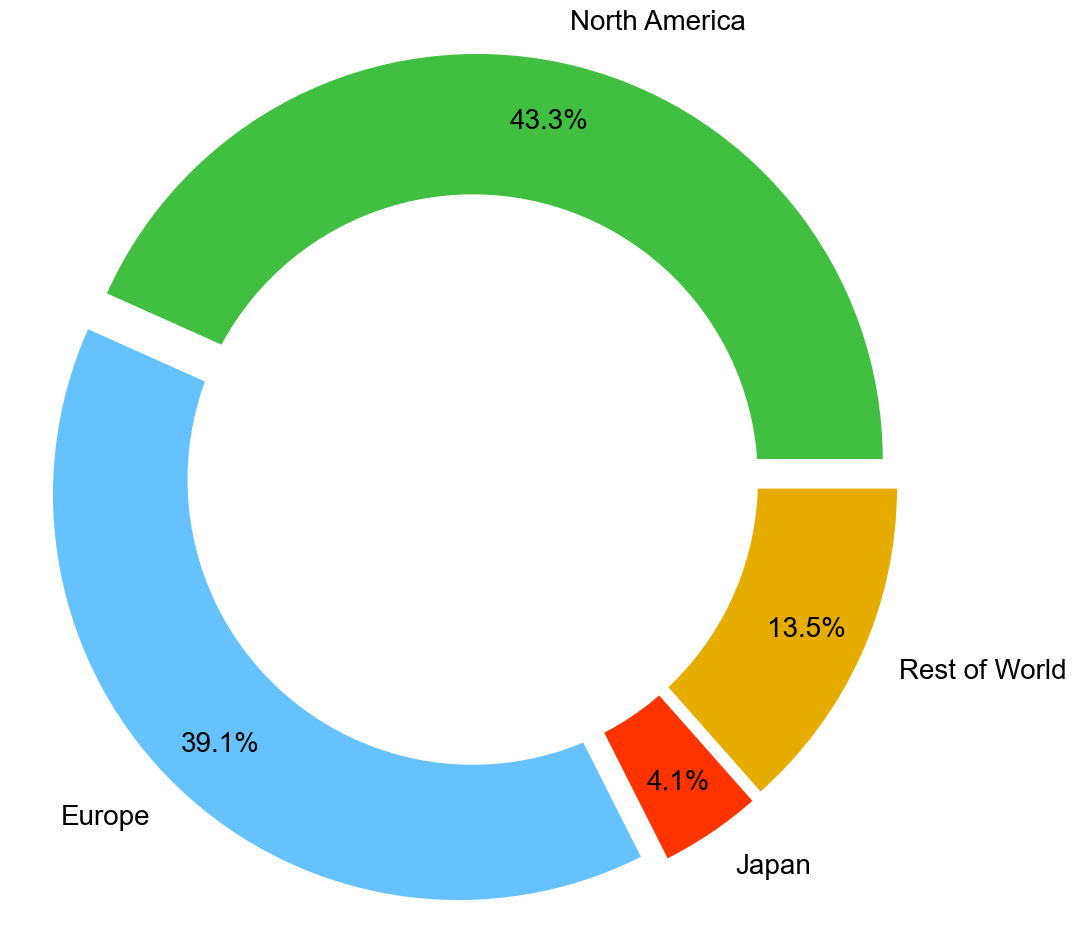

In [38]:
zones = [all_games['North America'].sum(), all_games.Europe.sum(), all_games.Japan.sum(), all_games['Rest of World'].sum()]
labels = ['North America', 'Europe', 'Japan', 'Rest of World']
colors = ['#40bf40', '#66c2ff', '#ff3300', '#e6ac00']
explode = [0.05, 0.05, 0.05, 0.05]

plt.rc('figure', figsize = (12, 12))

fig, ax = plt.subplots()
ax.pie(zones, labels = labels, autopct = '%.1f%%', colors = colors, explode = explode, 
        textprops=dict(color="k", fontsize=20), pctdistance=0.85)

# Create the donut aspect
centre_circle = plt.Circle((0, 0), 0.70, fc='white')
fig = plt.gcf()
ax.add_artist(centre_circle)

ax.axis('equal')

plt.show()

Now, where does the revenue from the most sold games come from? 

In [39]:
all_games.head(6)

,Game,Year,Genre,Publisher,North America,Europe,Japan,Rest of World,Global
Game_ID,,,,,,,,,
0,Grand Theft Auto V,2014.0,Action,Rockstar Games,6.06,9.71,0.60,3.02,19.39
1,Call of Duty: Black Ops 3,2015.0,Shooter,Activision,6.18,6.05,0.41,2.44,15.09
2,Red Dead Redemption 2,2018.0,Action-Adventure,Rockstar Games,5.26,6.21,0.21,2.26,13.94
3,Call of Duty: WWII,2017.0,Shooter,Activision,4.67,6.21,0.40,2.12,13.40
4,FIFA 18,2017.0,Sports,EA Sports,1.27,8.64,0.15,1.73,11.80
5,FIFA 17,2016.0,Sports,Electronic Arts,1.26,7.95,0.12,1.61,10.94


C:\Users\91908\AppData\Local\Temp\ipykernel_13872\3137514558.py:18: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ax[axis_index[0], axis_index[1]].set_title("%s" % all_games.iloc[i][0], fontsize=14)


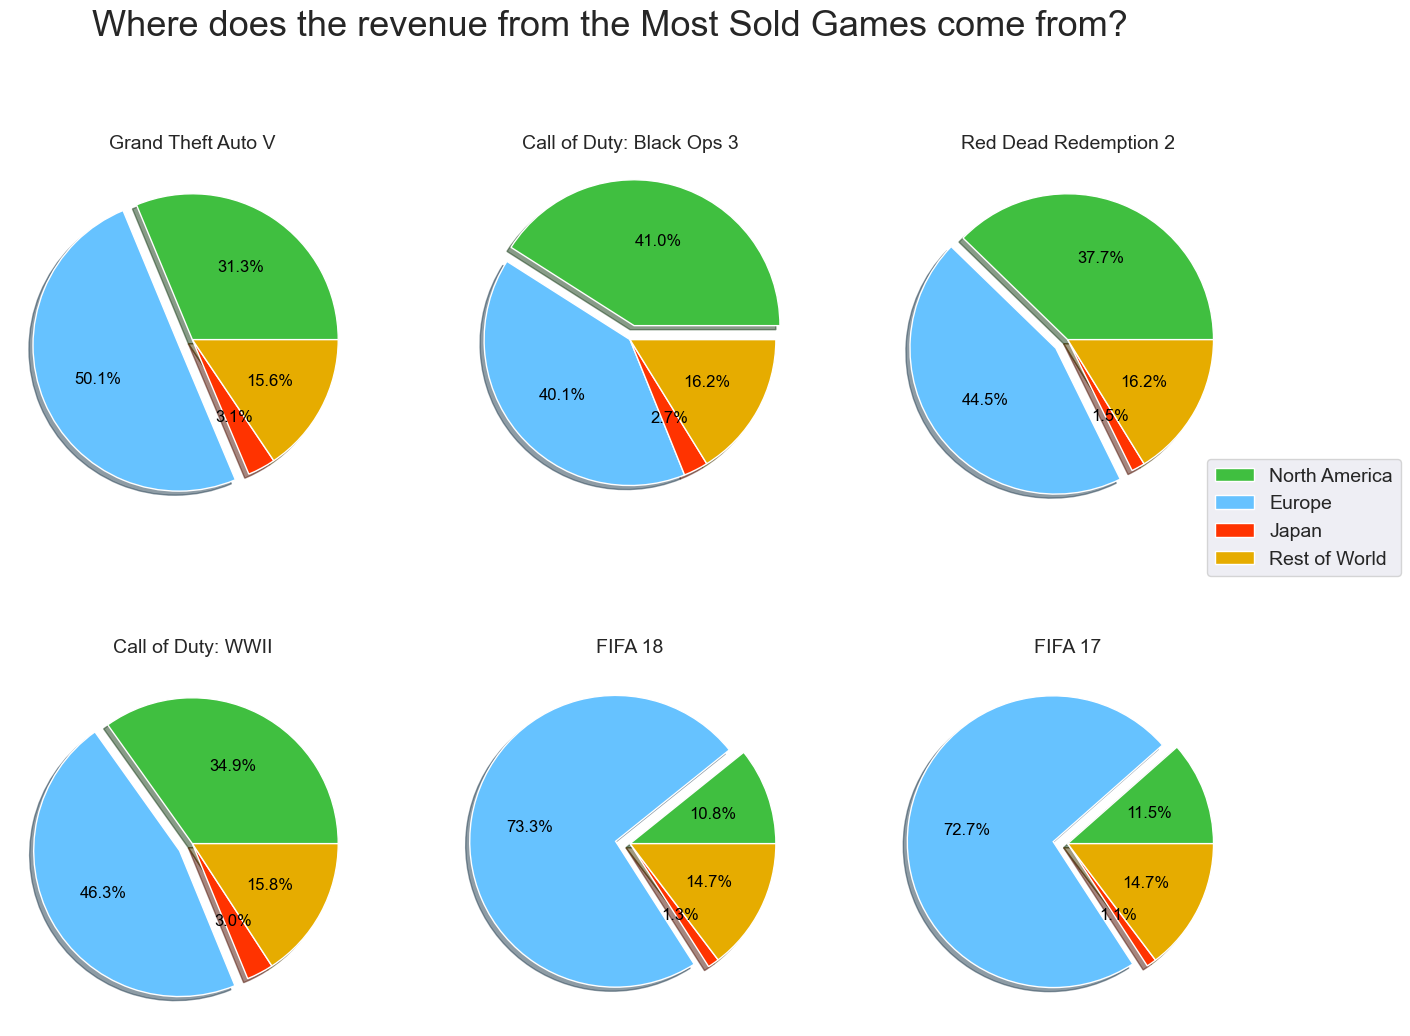

In [40]:
plt.rc('figure', figsize = (16, 12))
fig, ax = plt.subplots(2, 3)

for i in range(6):
  # Organize the subplots
  axis_index = [0 if i < 3 else 1, i if i < 3 else i % 3]

  # Collect the data and explode the index with biggest value
  game_data = list(all_games.iloc[i][4:8])
  index_biggest_value_game_data = np.argmax(game_data)
  local_explode = [0, 0, 0, 0]
  local_explode[index_biggest_value_game_data] += 0.1
  
  # Create the pie for each game and set its title
  ax[axis_index[0], axis_index[1]].pie(game_data, autopct = '%.1f%%', colors = colors, explode = local_explode, 
                                       textprops=dict(color="k", fontsize=12), shadow = True)
  
  ax[axis_index[0], axis_index[1]].set_title("%s" % all_games.iloc[i][0], fontsize=14)


# Legend in the figure and a super title
fig.legend(labels, fontsize = 14, loc = 'center right')
plt.suptitle('Where does the revenue from the Most Sold Games come from?', fontsize = 26)
plt.show()

Europe is the biggest market in most sold games, mainly in football games, as showed in FIFA 18 and FIFA 17. North America is close when it comes to shooter and actions games like Call of Duty and Red Dead Redemption.

Finally, let's consider the games that sold more than every other zone in each zone, for example FIFA 18 sold more in Europe in comparision with others zones. The code below considers the zone that has the most sales of each game.

In [41]:
games_most_sold_for_zone = np.array([np.argmax(row[['North America', 'Europe', 'Japan', 'Rest of World']]) for i, row in all_games.iterrows()])

games_sold_more_north_america = all_games[games_most_sold_for_zone == 0] # North America
games_sold_more_europe        = all_games[games_most_sold_for_zone == 1] # Europe
games_sold_more_japan         = all_games[games_most_sold_for_zone == 2] # Japan 

In [42]:
(games_most_sold_for_zone == 3).sum()

np.int64(0)

There aren't games that were sold more in the rest of the world than the other zones.

In [43]:
games_sold_more_north_america['Zone'] = ['North America'] * len(games_sold_more_north_america)
games_sold_more_europe['Zone'] = ['Europe'] * len(games_sold_more_europe)
games_sold_more_japan['Zone'] = ['Japan'] * len(games_sold_more_japan)

C:\Users\91908\AppData\Local\Temp\ipykernel_13872\808562512.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  games_sold_more_north_america['Zone'] = ['North America'] * len(games_sold_more_north_america)
C:\Users\91908\AppData\Local\Temp\ipykernel_13872\808562512.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  games_sold_more_europe['Zone'] = ['Europe'] * len(games_sold_more_europe)
C:\Users\91908\AppData\Local\Temp\ipykernel_13872\808562512.py:3: SettingWithCopyWarning: 
A value is trying to be set 

In [44]:
top_4_each_zone = pd.concat([games_sold_more_north_america.head(4)[['Game', 'North America', 'Zone']].rename(columns = {'North America': 'Zone Revenue'}),
                             games_sold_more_europe.head(4)[['Game', 'Europe', 'Zone']].rename(columns = {'Europe': 'Zone Revenue'}),
                             games_sold_more_japan.head(4)[['Game', 'Japan', 'Zone']].rename(columns = {'Japan': 'Zone Revenue'})])

top_4_each_zone

,Game,Zone Revenue,Zone
Game_ID,,,
1,Call of Duty: Black Ops 3,6.18,North America
6,Uncharted (PS4),4.49,North America
7,Spider-Man (PS4),3.64,North America
11,Star Wars Battlefront 2015,3.31,North America
0,Grand Theft Auto V,9.71,Europe
2,Red Dead Redemption 2,6.21,Europe
3,Call of Duty: WWII,6.21,Europe
4,FIFA 18,8.64,Europe
24,Monster Hunter: World,2.17,Japan


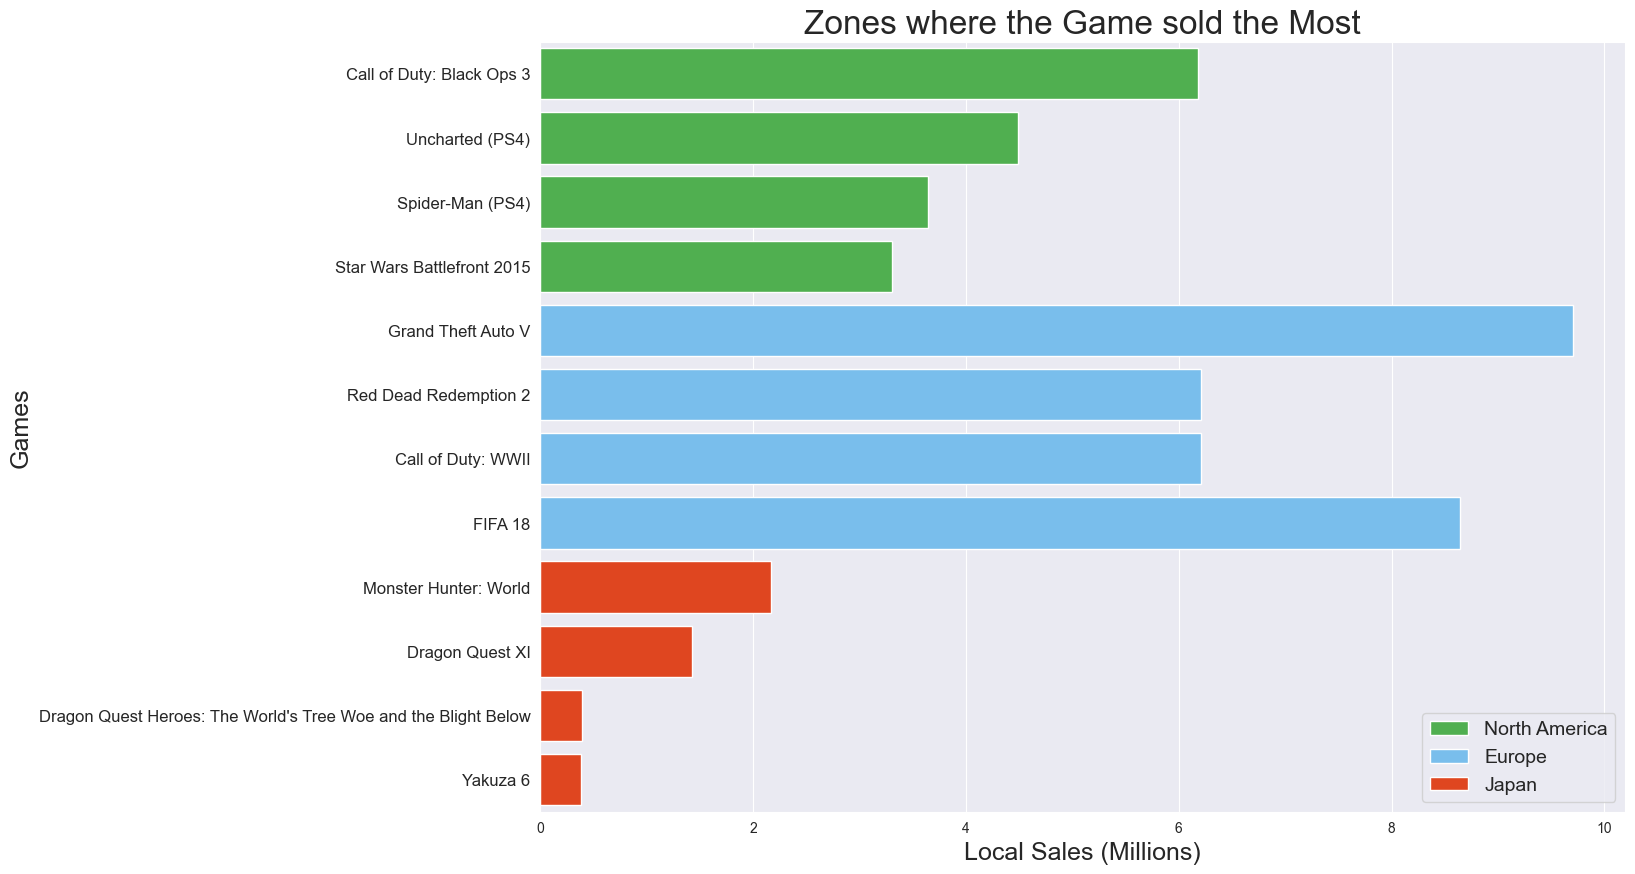

In [45]:
ax = sns.barplot(data = top_4_each_zone, x = 'Zone Revenue', y = 'Game', hue = 'Zone', dodge = False, palette = colors[:-1])
ax.set_title('Zones where the Game sold the Most', fontsize=24)
ax.set_ylabel('Games', fontsize=18)
ax.set_xlabel('Local Sales (Millions)', fontsize=18)
plt.legend(loc = 'lower right', fontsize = 14)
plt.yticks(fontsize = 12)
ax.figure.set_size_inches(14, 10)
plt.show()